In [3]:
import os

# --- Optimize CPU Threading for i7 12th Gen ---
# Prevents thread thrashing across P-cores and E-cores
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1"  # Accelerate matrix ops with Intel oneDNN

import cv2
import numpy as np
import tensorflow as tf

# Configure TensorFlow inter/intra parallelism for multi-core CPUs
tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(2)
cv2.setNumThreads(4)

print("TensorFlow running on CPU with oneDNN optimizations enabled.")

TensorFlow running on CPU with oneDNN optimizations enabled.


In [4]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Load original partition
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# 2. Explicit Split: Split 50k train set into 42,500 Train and 7,500 Validation (85/15 split)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# 3. Scale pixel values [0, 255] -> [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Train set shape      : {X_train.shape} ({X_train.shape[0]} samples)")
print(f"Validation set shape : {X_val.shape}   ({X_val.shape[0]} samples)")
print(f"Test set shape       : {X_test.shape}  ({X_test.shape[0]} samples)")

Train set shape      : (42500, 32, 32, 3) (42500 samples)
Validation set shape : (7500, 32, 32, 3)   (7500 samples)
Test set shape       : (10000, 32, 32, 3)  (10000 samples)


In [6]:
from skimage.feature import hog
from joblib import Parallel, delayed

def _process_single_image(img):
    img_uint8 = (img * 255).astype('uint8')
    
    # A. HOG Features
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    hog_feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False
    )
    
    # B. HSV Color Histogram
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    hist_h = cv2.calcHist([hsv], [0], None, [16], [0, 180])
    hist_s = cv2.calcHist([hsv], [1], None, [8], [0, 256])
    hist_v = cv2.calcHist([hsv], [2], None, [8], [0, 256])
    color_hist = np.concatenate([hist_h, hist_s, hist_v]).flatten()
    color_hist /= (color_hist.sum() + 1e-7)
    
    # C. Color Moments
    means = np.mean(img, axis=(0, 1))
    stds = np.std(img, axis=(0, 1))
    moments = np.concatenate([means, stds])
    
    return np.hstack([hog_feat, color_hist, moments])

def extract_handcrafted_features_fast(images, n_jobs=-1):
    # Process images in parallel across all CPU cores
    results = Parallel(n_jobs=n_jobs, batch_size=256)(
        delayed(_process_single_image)(img) for img in images
    )
    return np.array(results)

print("Extracting features in parallel using all available CPU threads...")
X_train_hc = extract_handcrafted_features_fast(X_train)
X_val_hc   = extract_handcrafted_features_fast(X_val)
X_test_hc  = extract_handcrafted_features_fast(X_test)

Extracting features in parallel using all available CPU threads...


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# 1. Feature Normalization
scaler = StandardScaler()
X_train_hc = scaler.fit_transform(X_train_hc)
X_val_hc   = scaler.transform(X_val_hc)
X_test_hc  = scaler.transform(X_test_hc)

# Ensure y_train, y_val, and y_test are clean 1D arrays
y_train_1d = y_train.ravel()
y_val_1d   = y_val.ravel()
y_true     = y_test.ravel()

# 2. Fast CPU Multi-Layer Perceptron
mlp_hc = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    activation='relu',
    solver='adam',
    max_iter=30,
    batch_size=128,       # Optimized for CPU vectorized operations
    early_stopping=False, # Disabled internal split to preserve full training data
    random_state=42,
    verbose=True
)

# 3. Fit model
mlp_hc.fit(X_train_hc, y_train_1d)

# 4. Evaluation
y_pred_hc = mlp_hc.predict(X_test_hc)
test_acc_hc = accuracy_score(y_true, y_pred_hc)
print(f"\n[Optimized CPU Handcrafted MLP] Test Accuracy: {test_acc_hc * 100:.2f}%")

Iteration 1, loss = 1.25538737
Iteration 2, loss = 0.97938978
Iteration 3, loss = 0.85072912
Iteration 4, loss = 0.73667290
Iteration 5, loss = 0.63638242
Iteration 6, loss = 0.54446510
Iteration 7, loss = 0.44413514
Iteration 8, loss = 0.34626613
Iteration 9, loss = 0.27533359
Iteration 10, loss = 0.21772659
Iteration 11, loss = 0.23369672
Iteration 12, loss = 0.15617330
Iteration 13, loss = 0.11626644
Iteration 14, loss = 0.11830237
Iteration 15, loss = 0.12917943
Iteration 16, loss = 0.11543162
Iteration 17, loss = 0.20796979
Iteration 18, loss = 0.07098263
Iteration 19, loss = 0.04649141
Iteration 20, loss = 0.06925134
Iteration 21, loss = 0.09954834
Iteration 22, loss = 0.10274135
Iteration 23, loss = 0.09548356
Iteration 24, loss = 0.08718813
Iteration 25, loss = 0.09288598
Iteration 26, loss = 0.11220425
Iteration 27, loss = 0.05145023
Iteration 28, loss = 0.04948808
Iteration 29, loss = 0.07523041
Iteration 30, loss = 0.08173795
Training loss did not improve more than tol=0.000

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Guide_Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3584 - loss: 1.7345 - val_accuracy: 0.4437 - val_loss: 1.5050
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.5043 - loss: 1.3765 - val_accuracy: 0.5363 - val_loss: 1.2688
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.5703 - loss: 1.2138 - val_accuracy: 0.6025 - val_loss: 1.1232
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6112 - loss: 1.1033 - val_accuracy: 0.6327 - val_loss: 1.0431
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.6421 - loss: 1.0232 - val_accuracy: 0.6425 - val_loss: 0.9900
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6683 - loss: 0.9509 - val_accuracy: 0.6741 - val_loss: 0.9317
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.6867 - loss: 0.8964 - val_accuracy: 0.6831 - val_loss: 0.9138
Epoch 8/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7063 - loss: 0.8438 - val_acc

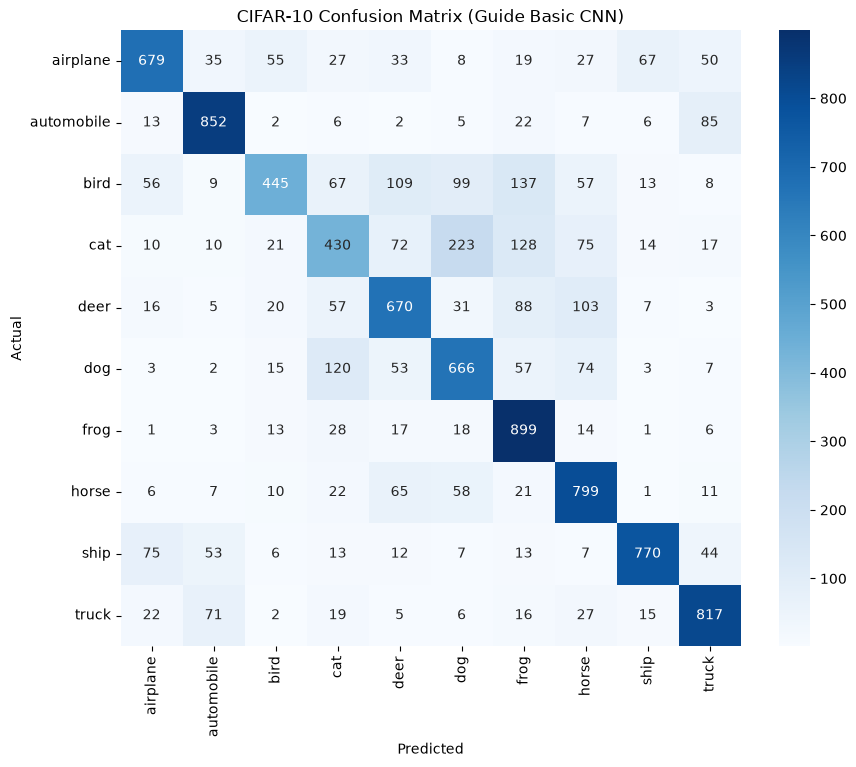

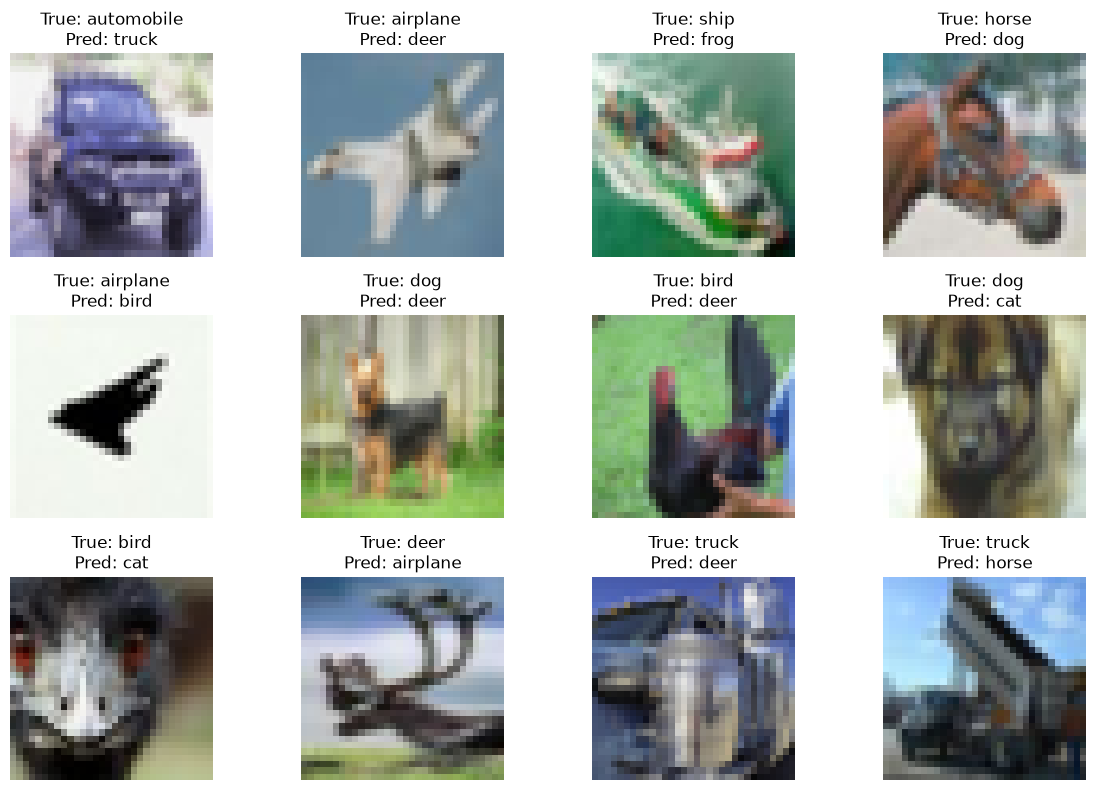

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Data & Explicit Validation Split ---
(X_train_full, y_train_full), (X_test_raw, y_test_raw) = cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 85/15 Stratified Split (No Data Leakage)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# Normalize Pixels [0, 255] -> [0.0, 1.0]
X_train = X_train_raw.astype('float32') / 255.0
X_val = X_val_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

# --- 3. Build Guide CNN Model ---
model_guide_cnn = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
], name="Guide_Basic_CNN")

model_guide_cnn.summary()

# --- 4. Compile ---
model_guide_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# --- 5. Train ---
history_guide_cnn = model_guide_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val)
)

# --- 6. Evaluate & Predict ---
test_loss, test_accuracy = model_guide_cnn.evaluate(X_test, y_test, verbose=0)
print(f"\n[Guide Basic CNN] Test Accuracy: {test_accuracy * 100:.2f}%\n")

predictions = model_guide_cnn.predict(X_test)
y_pred = predictions.argmax(axis=1)
y_true = y_test.flatten()

# --- 7. Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CIFAR-10 Confusion Matrix (Guide Basic CNN)")
plt.show()

# --- 8. Display Incorrect Predictions ---
wrong = [i for i in range(len(y_test)) if y_true[i] != y_pred[i]]

plt.figure(figsize=(12, 8))
for j, i in enumerate(wrong[:12]):
    plt.subplot(3, 4, j + 1)
    plt.imshow(X_test_raw[i]) # Display original RGB
    plt.title(f"True: {class_names[y_true[i]]}\nPred: {class_names[y_pred[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [10]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

# Define Keras Augmentation Sequential Block
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1)
], name="Data_Augmentation")

# Build CNN with integrated augmentation
model_aug_cnn = Sequential([
    data_augmentation,
    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
], name="Guide_Augmented_CNN")

model_aug_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train Augmented CNN
history_aug_cnn = model_aug_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val)
)

test_loss_aug, test_acc_aug = model_aug_cnn.evaluate(X_test, y_test, verbose=0)
print(f"\n[Guide Augmented CNN] Test Accuracy: {test_acc_aug * 100:.2f}%\n")

Epoch 1/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3198 - loss: 1.8312 - val_accuracy: 0.4396 - val_loss: 1.5233
Epoch 2/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4458 - loss: 1.5373 - val_accuracy: 0.4695 - val_loss: 1.5451
Epoch 3/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4854 - loss: 1.4322 - val_accuracy: 0.5473 - val_loss: 1.2669
Epoch 4/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.5171 - loss: 1.3483 - val_accuracy: 0.5593 - val_loss: 1.2471
Epoch 5/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5389 - loss: 1.2929 - val_accuracy: 0.5889 - val_loss: 1.1490
Epoch 6/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5592 - loss: 1.2467 - val_accuracy: 0.5804 - val_loss: 1.2073
Epoch 7/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.5705 - loss: 1.2187 - val_accuracy: 0.5805 - val_loss: 1.2156
Epoch 8/15
665/665 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.5852 - loss: 1.1841 - va

In [12]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint

# 1. Define Model Checkpoint Callbacks
checkpoint_basic = ModelCheckpoint(
    filepath="cifar10_guide_basic_cnn.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

checkpoint_aug = ModelCheckpoint(
    filepath="cifar10_guide_augmented_cnn.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

# 2. Train Basic CNN (Saves automatically on best val_accuracy)
history_guide_cnn = model_guide_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_basic]
)

# 3. Train Augmented CNN (Saves automatically on best val_accuracy)
history_aug_cnn = model_aug_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_aug]
)

Epoch 1/15
370/665 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7984 - loss: 0.5708

KeyboardInterrupt: 

In [13]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, 
    GlobalAveragePooling2D, Dense, Dropout, RandomFlip, RandomRotation
)
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- 1. CPU Runtime Optimization for i7 12th Gen ---
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1"

tf.config.threading.set_intra_op_parallelism_threads(8)
tf.config.threading.set_inter_op_parallelism_threads(2)

# --- 2. Data Preparation ---
(X_train_full, y_train_full), (X_test_raw, y_test_raw) = cifar10.load_data()

# 85/15 Stratified Split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# Normalize Pixels to [0, 1]
X_train = X_train_raw.astype('float32') / 255.0
X_val   = X_val_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32') / 255.0

# --- 3. Build Improved CPU-Friendly CNN Architecture ---
def build_improved_cnn():
    model = Sequential([
        # Augmentation Block (Inline)
        RandomFlip("horizontal", input_shape=(32, 32, 3)),
        RandomRotation(0.05),

        # Block 1
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(32, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        Conv2D(64, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Block 3
        Conv2D(128, (3, 3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        # Dense Head (Global Average Pooling minimizes parameters for fast CPU computation)
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(10, activation='softmax')
    ], name="Improved_CPU_CNN")
    
    return model

model_improved = build_improved_cnn()
model_improved.summary()

# --- 4. Compile & Configure Callbacks ---
model_improved.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Automatic Model Saving & Learning Rate Decay
callbacks = [
    ModelCheckpoint(
        filepath="cifar10_improved_cnn_best.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]

# --- 5. Train Improved CNN ---
print("\nTraining Improved CNN (Optimized for Fast CPU Runtime)...")
history_improved = model_improved.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

# --- 6. Evaluate & Save Final Benchmarks ---
test_loss_imp, test_acc_imp = model_improved.evaluate(X_test, y_test_raw, verbose=0)
print(f"\n==================================================")
print(f"[Improved CNN] Test Accuracy: {test_acc_imp * 100:.2f}%")
print(f"Model saved automatically to 'cifar10_improved_cnn_best.keras'")
print(f"==================================================")

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Improved_CPU_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 159,018 (621.16 KB)

 Trainable params: 158,122 (617.66 KB)

 Non-trainable params: 896 (3.50 KB)


Training Improved CNN (Optimized for Fast CPU Runtime)...
Epoch 1/20
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.3710 - loss: 1.7913
Epoch 1: val_accuracy improved from None to 0.42333, saving model to cifar10_improved_cnn_best.keras

Epoch 1: finished saving model to cifar10_improved_cnn_best.keras
665/665 ━━━━━━━━━━━━━━━━━━━━ 57s 81ms/step - accuracy: 0.3710 - loss: 1.7912 - val_accuracy: 0.4233 - val_loss: 1.6116 - learning_rate: 0.0010
Epoch 2/20
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5272 - loss: 1.3077
Epoch 2: val_accuracy improved from 0.42333 to 0.44373, saving model to cifar10_improved_cnn_best.keras

Epoch 2: finished saving model to cifar10_improved_cnn_best.keras
665/665 ━━━━━━━━━━━━━━━━━━━━ 54s 80ms/step - accuracy: 0.5272 - loss: 1.3076 - val_accuracy: 0.4437 - val_loss: 1.7353 - learning_rate: 0.0010
Epoch 3/20
664/665 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.5897 - loss: 1.1464
Epoch 3: val_accuracy did not improve from 0.44373
665/

In [15]:
# ---------------------------------------------------------------
# Fast + more accurate CIFAR-10 CNN (paste into one notebook cell)
# Assumes X_train, X_val, X_test (float32 in [0,1]) and
# y_train, y_val, y_test_raw already exist from your earlier cells.
# ---------------------------------------------------------------
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

DEV_MODE = False      # True: 10k-image subset, 8 epochs (quick iteration)
                     # False: full training set, 40 epochs
DEEP     = False     # False: ~15M MACs/img (CPU friendly)
                     # True : ~34M MACs/img (use on Colab GPU, try WIDTH=64)
WIDTH    = 32
BATCH    = 128
AUTOTUNE = tf.data.AUTOTUNE

# ---- data ----------------------------------------------------
y_tr_all = y_train.ravel()
y_va_all = y_val.ravel()
y_te     = y_test_raw.ravel()

if DEV_MODE:
    idx = np.random.RandomState(0).permutation(len(X_train))[:10_000]
    X_tr, y_tr = X_train[idx], y_tr_all[idx]
    X_va, y_va = X_val[:2000], y_va_all[:2000]
    EPOCHS = 8
else:
    X_tr, y_tr = X_train, y_tr_all
    X_va, y_va = X_val, y_va_all
    EPOCHS = 40

to_oh = lambda y: tf.keras.utils.to_categorical(y, 10)   # needed for label smoothing

# Cheap augmentation: flip + small shift (rotation is costlier and helps less on CIFAR)
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.125, 0.125, fill_mode="reflect"),
])

train_ds = (tf.data.Dataset.from_tensor_slices((X_tr, to_oh(y_tr)))
            .shuffle(10_000)
            .batch(BATCH)
            .map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))
val_ds = (tf.data.Dataset.from_tensor_slices((X_va, to_oh(y_va)))
          .batch(256).prefetch(AUTOTUNE))

# ---- model ---------------------------------------------------
norm = layers.Normalization()          # per-channel mean/std
norm.adapt(X_tr)

def conv_bn(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    return layers.Activation("relu")(x)

def build_model(width=32, deep=False):
    inp = layers.Input((32, 32, 3))
    x = norm(inp)
    x = conv_bn(x, width)                       # 32x32 (cheap: only 3 input channels)
    x = layers.MaxPooling2D()(x)                # -> 16x16, pool BEFORE the expensive convs
    x = conv_bn(x, width * 2)
    if deep: x = conv_bn(x, width * 2)
    x = layers.MaxPooling2D()(x)                # -> 8x8
    x = conv_bn(x, width * 4)
    if deep: x = conv_bn(x, width * 4)
    x = layers.MaxPooling2D()(x)                # -> 4x4
    x = conv_bn(x, width * 8)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)                  # only dropout: after BN, before classifier
    out = layers.Dense(10, activation="softmax")(x)
    return models.Model(inp, out, name="Fast_CNN")

model = build_model(WIDTH, DEEP)
model.summary()

# ---- compile: cosine LR, AdamW, label smoothing --------------
steps_per_epoch = int(np.ceil(len(X_tr) / BATCH))
lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=3e-3,
    decay_steps=EPOCHS * steps_per_epoch,
    alpha=0.01,
)
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=5e-3),  # tune 1e-4..1e-2
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"],
)

ckpt = tf.keras.callbacks.ModelCheckpoint(
    "cifar10_fast_cnn_best.keras", monitor="val_accuracy",
    mode="max", save_best_only=True,
)

# ---- train ---------------------------------------------------
t0 = time.time()
history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds,
                    callbacks=[ckpt], verbose=2)
print(f"\nTotal train time: {time.time() - t0:.0f}s "
      f"({(time.time() - t0) / EPOCHS:.1f}s/epoch)")

# ---- evaluate: plain + flip test-time augmentation -----------
best = tf.keras.models.load_model("cifar10_fast_cnn_best.keras")
p        = best.predict(X_test, batch_size=256, verbose=0)
p_flip   = best.predict(X_test[:, :, ::-1, :], batch_size=256, verbose=0)
acc      = (p.argmax(1) == y_te).mean()
acc_tta  = ((p + p_flip).argmax(1) == y_te).mean()
print(f"Test accuracy         : {acc * 100:.2f}%")
print(f"Test accuracy (+flip) : {acc_tta * 100:.2f}%")

Model: "Fast_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 32, 32, 3)      │             7 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 4, 4, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,433 (1.50 MB)

 Trainable params: 391,466 (1.49 MB)

 Non-trainable params: 967 (3.78 KB)

Epoch 1/40


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


333/333 - 46s - 137ms/step - accuracy: 0.4780 - loss: 1.6388 - val_accuracy: 0.5265 - val_loss: 1.5707
Epoch 2/40
333/333 - 34s - 103ms/step - accuracy: 0.6093 - loss: 1.3818 - val_accuracy: 0.5944 - val_loss: 1.4363
Epoch 3/40
333/333 - 33s - 99ms/step - accuracy: 0.6645 - loss: 1.2751 - val_accuracy: 0.6647 - val_loss: 1.2652
Epoch 4/40
333/333 - 34s - 102ms/step - accuracy: 0.6986 - loss: 1.2074 - val_accuracy: 0.6823 - val_loss: 1.2583
Epoch 5/40
333/333 - 35s - 105ms/step - accuracy: 0.7259 - loss: 1.1535 - val_accuracy: 0.6993 - val_loss: 1.1995
Epoch 6/40
333/333 - 68s - 205ms/step - accuracy: 0.7420 - loss: 1.1206 - val_accuracy: 0.6515 - val_loss: 1.3350
Epoch 7/40
333/333 - 75s - 224ms/step - accuracy: 0.7597 - loss: 1.0891 - val_accuracy: 0.7052 - val_loss: 1.1906
Epoch 8/40
333/333 - 87s - 260ms/step - accuracy: 0.7703 - loss: 1.0646 - val_accuracy: 0.7688 - val_loss: 1.0522
Epoch 9/40
333/333 - 60s - 179ms/step - accuracy: 0.7818 - loss: 1.0422 - val_accuracy: 0.7485 - val